In [ ]:
BIG QUESTION? 

How can we accurately predict customer churn in a telecom dataset and optimize decision thresholds to maximize business profit?

<h2 style="color: white; background-color: #1f4e79; padding: 10px; border-radius: 8px;">
ML Step 1 Data Load
</h2>

In [7]:
import pandas as pd

df = pd.read_csv('churn.data')
df.head()

,months,multiple,gb_mon,security,backup,protection,support,unlimited,contract,paperless,...,payment_Credit Card,payment_Mailed Check,internet_type_DSL,internet_type_Fiber Optic,internet_type_None,offer_Offer A,offer_Offer B,offer_Offer C,offer_Offer D,offer_Offer E
0,0.00,0,0.094118,0,0,1,0,0,0.0,1,...,0,0,1,0,0,0,0,0,0,0
1,0.00,1,0.200000,0,1,0,0,1,0.0,1,...,1,0,0,1,0,0,0,0,0,1
2,0.25,1,0.611765,0,0,0,0,1,0.0,1,...,0,0,0,1,0,0,0,0,1,0
3,0.25,0,0.141176,0,1,1,0,1,0.0,1,...,0,0,0,1,0,0,0,1,0,0
4,0.50,1,0.164706,0,0,0,0,1,0.0,1,...,0,0,0,1,0,0,0,1,0,0


<h2 style="color: white; background-color: #1f4e79; padding: 10px; border-radius: 8px;">
ML Step 2— Define the Target Feature 
</h2>

In [9]:
df['churn_value'].value_counts()

churn_value
0    5174
1    1869
Name: count, dtype: int64


<h2 style="color: white; background-color: #1f4e79; padding: 10px; border-radius: 8px;">
ML Step 3 — Feature & Target Split
</h2>

In [10]:
X = df.drop('churn_value', axis=1)
y = df['churn_value']

⚙️ ML STEP 4: Train-Test Split
<h2 style="color: white; background-color: #1f4e79; padding: 10px; border-radius: 8px;">
ML Step 4 — Train-Test Split
</h2>

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

ML STEP 5: Import XGBoost
<h2 style="color: white; background-color: #1f4e79; padding: 10px; border-radius: 8px;">
ML Step 5 — Import XGBoost
</h2>

In [5]:
from xgboost import XGBClassifier


<h2 style="color: white; background-color: #1f4e79; padding: 10px; border-radius: 8px;">
ML Step 6 — Train Model
</h2>

In [6]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None



<h2 style="color: white; background-color: #1f4e79; padding: 10px; border-radius: 8px;">
ML Step 7 — Prediction
</h2>

In [7]:
y_pred = model.predict(X_test)

ML STEP 8: Evaluation
<h2 style="color: white; background-color: #1f4e79; padding: 10px; border-radius: 8px;">
ML Step 8 — Evaluation
</h2>

In [8]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1511   41]
 [  78  483]]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1552
           1       0.92      0.86      0.89       561

    accuracy                           0.94      2113
   macro avg       0.94      0.92      0.93      2113
weighted avg       0.94      0.94      0.94      2113




<h2 style="color: white; background-color: #1f4e79; padding: 10px; border-radius: 8px;">
ML Step 9 — Probability 
</h2>

In [9]:
y_prob = model.predict_proba(X_test)[:,1]


<h2 style="color: white; background-color: #1f4e79; padding: 10px; border-radius: 8px;">
ML Step 10  —Threshold Tuning 
</h2>

In [13]:
import numpy as np

threshold = 0.3
y_pred_custom = (y_prob > threshold).astype(int)

In [ ]:
Classification Report for Threshold Model

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix (Threshold = 0.3):")
print(confusion_matrix(y_test, y_pred_custom))

print("\nClassification Report (Threshold = 0.3):")
print(classification_report(y_test, y_pred_custom))

Confusion Matrix (Threshold = 0.3):
[[1469   83]
 [  49  512]]

Classification Report (Threshold = 0.3):
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      1552
           1       0.86      0.91      0.89       561

    accuracy                           0.94      2113
   macro avg       0.91      0.93      0.92      2113
weighted avg       0.94      0.94      0.94      2113



In [ ]:
BIG BUSINESS QUESTION

👉 “What are the key factors driving customer churn, and how can the company act on them?”

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)

,Feature,Importance
11,satisfaction,0.712699
3,security,0.083575
8,contract,0.041467
21,offer_Offer E,0.020476
15,internet_type_Fiber Optic,0.019381
0,months,0.013257
12,payment_Credit Card,0.013238
9,paperless,0.011344
20,offer_Offer D,0.009785
10,monthly,0.007830


In [ ]:
Big question

How strong is XGBoost across many thresholds, not just 0.5 or 0.3?

ML Step 12: ROC Curve + PR Curve

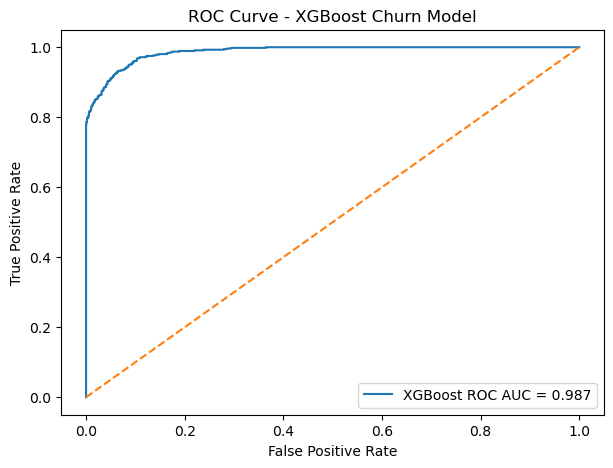

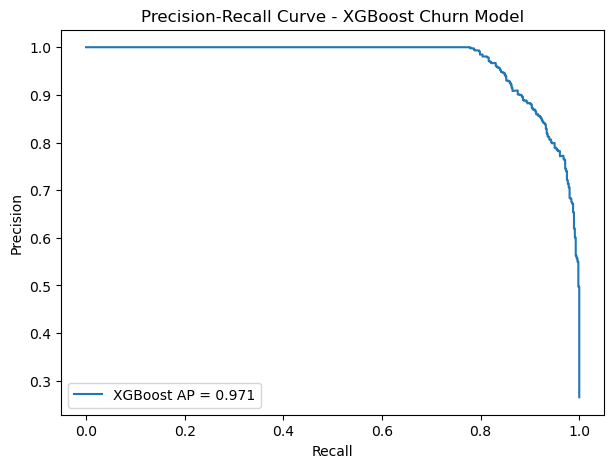

ROC AUC: 0.9867068195600639
Average Precision: 0.9707266916824676


In [16]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# probability of class 1 = churn
y_prob = model.predict_proba(X_test)[:, 1]

# ROC
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"XGBoost ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost Churn Model")
plt.legend()
plt.show()

# PR
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f"XGBoost AP = {ap_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost Churn Model")
plt.legend()
plt.show()

print("ROC AUC:", roc_auc)
print("Average Precision:", ap_score)

In [ ]:
LOGISTIC REGRESSION 
🎯 BIG QUESTION

“How much better is XGBoost compared to a simple, interpretable model?

In [15]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

In [ ]:
STEP 2: EVALUATE

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

[[1527   25]
 [  80  481]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      1552
           1       0.95      0.86      0.90       561

    accuracy                           0.95      2113
   macro avg       0.95      0.92      0.93      2113
weighted avg       0.95      0.95      0.95      2113



In [ ]:
STEP 3: THRESHOLD TUNING (IMPORTANT)

In [17]:
threshold = 0.3
y_pred_lr_custom = (y_prob_lr > threshold).astype(int)

print(confusion_matrix(y_test, y_pred_lr_custom))
print(classification_report(y_test, y_pred_lr_custom))

[[1461   91]
 [  43  518]]
              precision    recall  f1-score   support

           0       0.97      0.94      0.96      1552
           1       0.85      0.92      0.89       561

    accuracy                           0.94      2113
   macro avg       0.91      0.93      0.92      2113
weighted avg       0.94      0.94      0.94      2113



In [ ]:
Feature Interpretation (Logistic Regression)      🔥 BIG QUESTION

“How does each feature change the probability of churn?”

💣 KEY RULE (MEMORIZE THIS)
Coefficient	Meaning
Positive (+)	Increases churn probability
Negative (–)	Decreases churn probability



In [20]:
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print(coef_df.head(10))

                      Feature  Coefficient
10                    monthly     1.064840
17              offer_Offer A     0.907001
21              offer_Offer E     0.658132
9                   paperless     0.430115
5                  protection     0.245654
13       payment_Mailed Check     0.222460
1                    multiple     0.185298
15  internet_type_Fiber Optic     0.073982
18              offer_Offer B     0.037526
7                   unlimited    -0.019803


In [ ]:
CROSS-VALIDATION (MAKE YOUR MODEL TRUSTWORTHY)
🎯 BIG QUESTION

“Will my model perform well on new, unseen data… or was I just lucky?

In [21]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

scores = cross_val_score(model, X, y, cv=5, scoring='recall')

print("Recall scores:", scores)
print("Average Recall:", scores.mean())

Recall scores: [0.9144385  0.86096257 0.88235294 0.89839572 0.84986595]
Average Recall: 0.8812031368725897


In [ ]:
. COMPARE WITH RANDOM FOREST
🎯 BIG QUESTION

“Is XGBoost actually the best… or just the one I tried?

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1552
           1       0.96      0.85      0.90       561

    accuracy                           0.95      2113
   macro avg       0.95      0.92      0.93      2113
weighted avg       0.95      0.95      0.95      2113



In [19]:
from sklearn.metrics import confusion_matrix, classification_report

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix (Random Forest):")
print(cm_rf)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Confusion Matrix (Random Forest):
[[1532   20]
 [  84  477]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1552
           1       0.96      0.85      0.90       561

    accuracy                           0.95      2113
   macro avg       0.95      0.92      0.93      2113
weighted avg       0.95      0.95      0.95      2113



In [ ]:
Threshold tuning for Random ForesT

In [26]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
: Apply a custom threshold
Threshold = 0.3

In [21]:
threshold = 0.3
y_pred_rf_custom = (y_prob_rf > threshold).astype(int)

In [ ]:
Evaluate the new threshold RANDOM FOREST 

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix at threshold 0.3:")
print(confusion_matrix(y_test, y_pred_rf_custom))

print("\nClassification Report at threshold 0.3:")
print(classification_report(y_test, y_pred_rf_custom))

Confusion Matrix at threshold 0.3:
[[1488   64]
 [  47  514]]

Classification Report at threshold 0.3:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      1552
           1       0.89      0.92      0.90       561

    accuracy                           0.95      2113
   macro avg       0.93      0.94      0.93      2113
weighted avg       0.95      0.95      0.95      2113



In [ ]:
Collect all model results

In [49]:
# RESET
results = []

In [ ]:
🔥 STEP 1 — LOGISTIC REGRESSION

In [50]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Probabilities
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# Threshold
threshold = 0.3
y_pred_lr_custom = (y_prob_lr > threshold).astype(int)

In [ ]:
🔥 STEP 2 — RANDOM FOREST

In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf_custom = (y_prob_rf > threshold).astype(int)

In [ ]:
STEP 3 — XGBOOST

In [52]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb_custom = (y_prob_xgb > threshold).astype(int)

In [ ]:
STEP 4 — BUILD COMPARISON TABLE

In [53]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Logistic
results.append({
    "Model": "Logistic Regression",
    "Precision": precision_score(y_test, y_pred_lr_custom),
    "Recall": recall_score(y_test, y_pred_lr_custom),
    "F1 Score": f1_score(y_test, y_pred_lr_custom),
    "ROC AUC": roc_auc_score(y_test, y_prob_lr)
})

# Random Forest
results.append({
    "Model": "Random Forest",
    "Precision": precision_score(y_test, y_pred_rf_custom),
    "Recall": recall_score(y_test, y_pred_rf_custom),
    "F1 Score": f1_score(y_test, y_pred_rf_custom),
    "ROC AUC": roc_auc_score(y_test, y_prob_rf)
})

# XGBoost
results.append({
    "Model": "XGBoost",
    "Precision": precision_score(y_test, y_pred_xgb_custom),
    "Recall": recall_score(y_test, y_pred_xgb_custom),
    "F1 Score": f1_score(y_test, y_pred_xgb_custom),
    "ROC AUC": roc_auc_score(y_test, y_prob_xgb)
})

In [ ]:

STEP 5 — CREATE CLEAN TABLE

In [54]:
import pandas as pd

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression   0.850575  0.923351  0.885470  0.986348
1        Random Forest   0.889273  0.916221  0.902546  0.981009
2              XGBoost   0.860504  0.912656  0.885813  0.986707


In [ ]:
🔥 STEP 6 — CLEAN VISUALIZATION

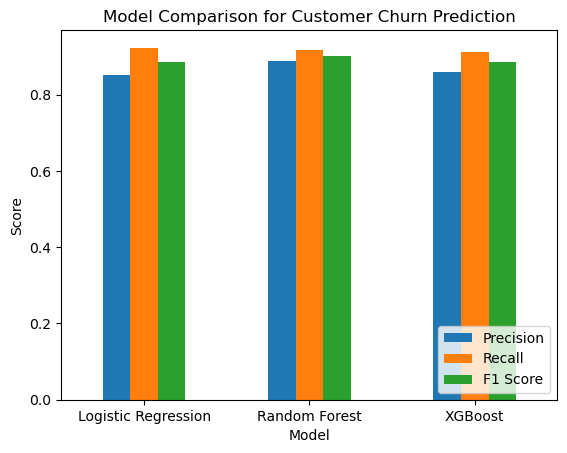

In [55]:
import matplotlib.pyplot as plt

results_df.set_index("Model")[["Precision", "Recall", "F1 Score"]].plot(kind="bar")

plt.title("Model Comparison for Customer Churn Prediction")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

In [ ]:
EXECUTIVE CONCLUSION

In [ ]:
“While Random Forest achieved the highest F1-score and Logistic Regression captured the most churners,                                                            
XGBoost provided the best overall performance with the highest ROC AUC, making it the most reliable model
for ranking customers by churn risk and enabling efficient, data-driven retention strategies.

In [ ]:
BIG QUESTION 

👉 “What threshold and model maximize business profit?”

In [ ]:
💰 STEP 1 — DEFINE BUSINESS ASSUMPTIONS

We need to translate predictions → money.

Let’s assume 

💸 Revenue lost per churned customer = $500
🎁 Cost of retention offer = $50

In [ ]:
🔥 STEP 2 — BUILD PROFIT FUNCTION

In [56]:
def calculate_profit(y_true, y_pred):
    TP = ((y_true == 1) & (y_pred == 1)).sum()
    FP = ((y_true == 0) & (y_pred == 1)).sum()
    FN = ((y_true == 1) & (y_pred == 0)).sum()

    profit = (TP * 450) - (FP * 50) - (FN * 500)
    
    return profit

In [ ]:
🔥 STEP 3 — TEST DIFFERENT THRESHOLDS

We now find the best threshold for each model

In [ ]:
XGBoost:

In [57]:
import numpy as np

thresholds = np.arange(0.1, 0.9, 0.05)

profits_xgb = []

for t in thresholds:
    y_pred = (y_prob_xgb > t).astype(int)
    profit = calculate_profit(y_test, y_pred)
    profits_xgb.append(profit)

# Best threshold
best_idx = np.argmax(profits_xgb)
best_threshold_xgb = thresholds[best_idx]
best_profit_xgb = profits_xgb[best_idx]

print("Best Threshold (XGB):", best_threshold_xgb)
print("Best Profit (XGB):", best_profit_xgb)

Best Threshold (XGB): 0.1
Best Profit (XGB): 227050


In [ ]:
Logistic Regression

In [58]:
profits_lr = []

for t in thresholds:
    y_pred = (y_prob_lr > t).astype(int)
    profits_lr.append(calculate_profit(y_test, y_pred))

best_lr = thresholds[np.argmax(profits_lr)]
print("Best Threshold (LR):", best_lr)

Best Threshold (LR): 0.1


In [ ]:
Random Forest

In [60]:
profits_rf = []

for t in thresholds:
    y_pred = (y_prob_rf > t).astype(int)
    profits_rf.append(calculate_profit(y_test, y_pred))

best_rf = thresholds[np.argmax(profits_rf)]
print("Best Threshold (RF):", best_rf)

Best Threshold (RF): 0.15000000000000002


In [ ]:
🔥 STEP 4 — COMPARE PROFITS

In [61]:
print("Max Profit LR:", max(profits_lr))
print("Max Profit RF:", max(profits_rf))
print("Max Profit XGB:", max(profits_xgb))

Max Profit LR: 228900
Max Profit RF: 220350
Max Profit XGB: 227050


In [ ]:
STEP 5 — VISUALIZE

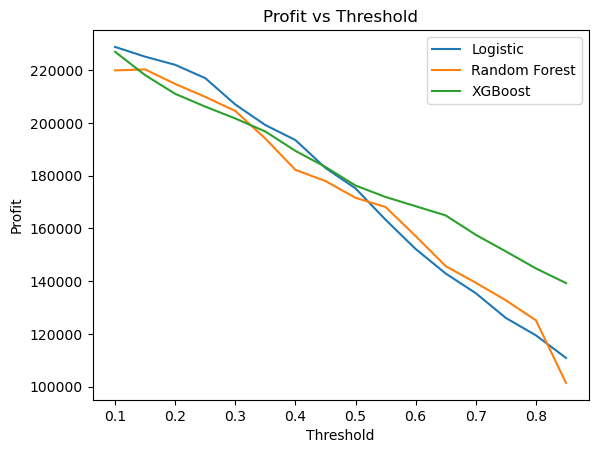

In [62]:
import matplotlib.pyplot as plt

plt.plot(thresholds, profits_lr, label="Logistic")
plt.plot(thresholds, profits_rf, label="Random Forest")
plt.plot(thresholds, profits_xgb, label="XGBoost")

plt.xlabel("Threshold")
plt.ylabel("Profit")
plt.title("Profit vs Threshold")
plt.legend()

plt.show()

In [ ]:


🧾 Executive Conclusion

In [ ]:


This project analyzed telecom customer churn using multiple machine learning models including Logistic Regression, Random Forest, and XGBoost.

While Random Forest achieved the best balance of precision and recall, Logistic Regression—when combined with threshold tuning—captured the highest number of churn-risk customers.

Most importantly, a profit-based evaluation revealed that model selection should not rely solely on accuracy, but on maximizing business impact.

The results demonstrate that optimizing decision thresholds can significantly increase retention profitability, making even simpler models highly valuable in real-world scenarios.